<a href="https://colab.research.google.com/github/siddhi-308-dotcom/ML/blob/main/exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

data = pd.read_csv('adult.data', names=columns, sep=',\s*', engine='python')
print(data.head())

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_452/2519162261.py:11: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv('adult.data', names=columns, sep=',\s*', engine='python')


   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [24]:

print(data.isnull().sum())

print(data.isin(['?']).sum())


print("Number of duplicate rows:", data.duplicated().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64
Number of duplicate rows: 24


In [25]:

data.replace('?', pd.NA, inplace=True)


data.dropna(inplace=True)

data.drop_duplicates(inplace=True)

print("Dataset shape after cleaning:", data.shape)

Dataset shape after cleaning: (30139, 15)


In [26]:
from sklearn.preprocessing import LabelEncoder
s
categorical_cols = data.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [27]:
from sklearn.model_selection import train_test_split

X = data.drop('income', axis=1)  # Features
y = data['income']               # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Initialize classifier
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Accuracy: 0.8088918380889184

Confusion Matrix:
 [[3917  568]
 [ 584  959]]


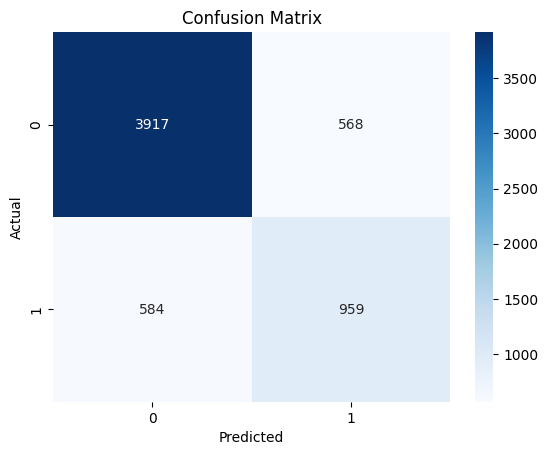


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      4485
           1       0.63      0.62      0.62      1543

    accuracy                           0.81      6028
   macro avg       0.75      0.75      0.75      6028
weighted avg       0.81      0.81      0.81      6028

ROC-AUC: 0.7474360780624694


In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt



accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)


roc_auc = roc_auc_score(y_test, y_pred)
print("ROC-AUC:", roc_auc)